In [1]:
import numpy as np
import pandas as pd
import torch
from torch import nn, optim
from torchvision import datasets, transforms, utils
from torchsummary import summary
import matplotlib.pyplot as plt

plt.rcParams.update({'axes.grid': False})

**Step 1: Download and prepare the MNIST dataset**

In [2]:
BATCH_SIZE = 64

# Define the transformation for preprocessing the data
# In this case, we convert the images to PyTorch tensors
transform = transforms.Compose([transforms.ToTensor()])

# Download and load the training dataset
# train=True means we are downloading the training split of MNIST
trainset = datasets.MNIST('data/', download=True, train=True, transform=transform)
validset = datasets.MNIST('data/', download=True, train=False, transform=transform)

len(trainset), len(validset)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 35.8MB/s]


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 1.50MB/s]

Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw



...

100%|██████████| 1.65M/1.65M [00:00<00:00, 13.9MB/s]


Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 5.56MB/s]

Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw



(60000, 10000)

In [ ]:
# bach loader

trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
validloader = torch.utils.data.DataLoader(validset, batch_size=BATCH_SIZE, shuffle=True)

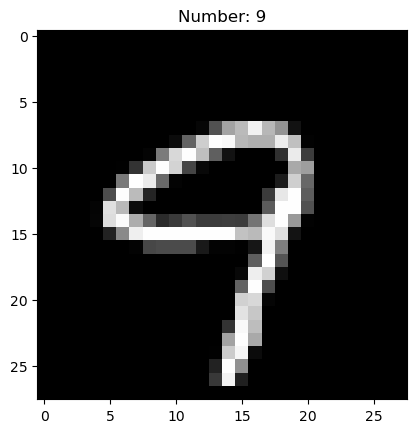

In [5]:
#visualize a sample from the training data

X, y = next(iter(trainloader))
plt.imshow(X[0, 0, :, :], cmap="gray")
plt.title(f"Number: {y[0].item()}");

**Step 2: Define the CNN architecture**

In [6]:
class MNIST_classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(1, 16, (5, 5)),
            nn.ReLU(), 
            nn.MaxPool2d((2, 2)),
            nn.Dropout(0.2),
            nn.Flatten(),
            nn.Linear(2304, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
        
    def forward(self, x):
        out = self.main(x)
        return out